### LOGISTIC REGRESSION MODELING

The following **Logistic Regression models** are built:

_Model L1_     
A simple model that is not balanced and not optimized.

_Model L2_   
The class imbalance is addressed by the parameter class_weight. The optimum combination of model parameters are determined using grid search.

_Model L3_    
The best threshold improves model performance.

_Model L4_    
Sequential Feature Selection further improves the model.

_Model L5_    
Random Forest Classifier is used for feature selection.

The following **metrics** are determined:    
_AUC_   
_Accuracy_    
_Precision_       
_Recall_    
_F2 Score_     
_Profit/Loss_    

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.

**Hyperparameters Tuning**    
Model hyperparameters are optimized using grid search to maximize model performance and to particularly address overfitting.  

**Feature Importance**     
The features and their importances are examined to verify the magnitude of features influence on customer churn.   

**Feature Selection**    
Feature selection reduces the number of features to improve the model and to lessen noise. When there is less noise, the interpretability of feature importance improves. Noise in this context is irrelevant information that obscures underlying patterns or relationships the model is trying to learn.  

**Sample Predictions**     
Sample predictions are demonstrated on unseen data.

**Import the required libraries**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

In [3]:
# Verify info prior to modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7937 entries, 0 to 7936
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   

In [4]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [5]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

**A Baseline Model**     
Before the first model is built, a baseline is established.  The other models to be built should beat the baseline performance **AUC**.

In [6]:
# Build a baseline model
baseline = DummyClassifier(strategy='stratified')
baseline.fit(X_train, y_train)

DummyClassifier(strategy='stratified')

In [7]:
# Evaluate baseline model using 'roc_auc'
y_proba = baseline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print(f'The baseline Receiver Operating Curve AUC is {roc_auc:.2f}')

The baseline Receiver Operating Curve AUC is 0.50


In [8]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction']

In [9]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                'usage_growth_rate','last_login_days_ago','monthly_fee','payment_failures','support_tickets',
                'avg_resolution_time','csat_score','escalations','email_open_rate','marketing_click_rate',
                'nps_score','referral_count','tenure_fee_interaction']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 19 numeric columns.


**Encode the categorical features**

In [10]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

In [11]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response']
nominal_cols = ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'payment_method',
                'discount_applied', 'price_increase_last_3m', 'complaint_type']

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 2 ordinal columns and 9 nominal columns.


In [12]:
# Verify 'contract_type' and 'survey_response'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts())

contract_type
Monthly      3941
Quarterly    2421
Yearly       1575
Name: count, dtype: int64 

survey_response
Satisfied      3940
Neutral        2385
Unsatisfied    1612
Name: count, dtype: int64


In [13]:
# Prepare the ordinal encoder
ordinal_encoder = OrdinalEncoder(
    categories=[
      ['Monthly','Quarterly','Yearly'],         # contract_type
      ['Unsatisfied','Neutral','Satisfied']     # survey_response
    ]
)

In [14]:
# Prepare the transformer for encoding categorical data and scaling the rest
transformer = make_column_transformer(
    (ordinal_encoder, ordinal_cols),
    (OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
    remainder=StandardScaler()
)
transformer

ColumnTransformer(remainder=StandardScaler(),
                  transformers=[('ordinalencoder',
                                 OrdinalEncoder(categories=[['Monthly',
                                                             'Quarterly',
                                                             'Yearly'],
                                                            ['Unsatisfied',
                                                             'Neutral',
                                                             'Satisfied']]),
                                 ['contract_type', 'survey_response']),
                                ('onehotencoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'country', 'city',
                                  'customer_segment', 'signup_channel',
                                  'payment_method', 'discount_applied',
                                  'price_increase_last_3m',
                                  'complaint_type'])])

**Build a simple Logistic Regression model**    
A simple Logistic Regression model is built and called **Model L1**.

In [15]:
# Build a pipeline for the simple model
lgr_pipe_simple = Pipeline([
    ('transformer', transformer),
    ('lgr', LogisticRegression(random_state=42))
])
lgr_pipe_simple.fit(X_train, y_train)
lgr_pipe_simple

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('lgr', LogisticRegression(random_state=42))])

In [16]:
# Accuracy of model on train and test data
lgr_pipe_simple_acc_train = lgr_pipe_simple.score(X_train, y_train)
lgr_pipe_simple_acc_test = lgr_pipe_simple.score(X_test, y_test)

print(f'The train accuracy of the model is {lgr_pipe_simple_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {lgr_pipe_simple_acc_test*100:.2f}%')

The train accuracy of the model is 90.74%
The test accuracy of the model is 90.81%


**Compare model accuracy with baseline accuracy**     
The model test accuracy is slightly better than the baseline (90.81% model accuracy vs 90.62% baseline accuracy).    


In [17]:
# Baseline accuracy
baseline_acc = y_test.value_counts(normalize=True).max()

print(f'The baseline accuracy for predicting majority class is {baseline_acc*100:.2f}%')

The baseline accuracy for predicting majority class is 90.62%


In [18]:
# Define Model L1 threshold (default)
threshold_L1 = 0.50

**Classification Report L1**          
This model prediction for non-churn (0) is 91% correct (precision). When the model predicts churn (1), however, it is only right 80% of the time.  The model is also able to catch only 3% of churners (recall).   

In [19]:
# Generate classification report L1
y_pred_L1 = lgr_pipe_simple.predict(X_test)

print(classification_report(y_test, y_pred_L1))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1439
           1       0.80      0.03      0.05       149

    accuracy                           0.91      1588
   macro avg       0.85      0.51      0.50      1588
weighted avg       0.90      0.91      0.87      1588



**Confusion Matrix L1**     
1,438 customers that do not churn are correctly predicted not to churn (true negatives) and 4 customers that churn are correctly predicted to churn (true positives) out of 1,588 samples (accuracy = 91%).     
1 customer that does not churn is incorrectly predicted to churn (false positive). Precision is 80%.
145 customers who churn are incorrectly predicted not to churn (false negatives). Recall is only 3%.     
The model finds 3% of actual churners (4 out of 149 churners) - 97% of churners are missed (145 out of 149 churners).     


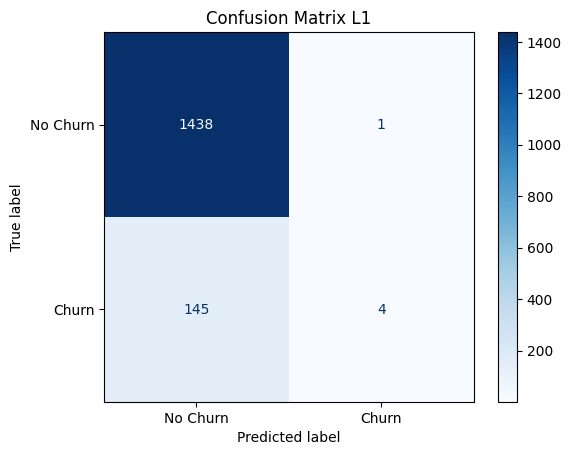

In [20]:
# Display confusion matrix L1
conf_matrix_L1 = confusion_matrix(y_test, y_pred_L1)
disp_L1 = ConfusionMatrixDisplay(conf_matrix_L1, display_labels=['No Churn','Churn'])
disp_L1.plot(cmap='Blues')
plt.title('Confusion Matrix L1')
plt.show()

In [21]:
# Values for false positive (fp_L1), false negative (fn_L1), true positive (tp_L1) and true negative (tn_L1)
fp_L1 = conf_matrix_L1[0][1]
fn_L1 = conf_matrix_L1[1][0]
tp_L1 = conf_matrix_L1[1][1]
tn_L1 = conf_matrix_L1[0][0]

print(f' fp_L1: {fp_L1} \n fn_L1: {fn_L1} \n tp_L1: {tp_L1} \n tn_L1: {tn_L1}')

 fp_L1: 1 
 fn_L1: 145 
 tp_L1: 4 
 tn_L1: 1438


In [22]:
# Calculations for accuracy, precision, recall
accuracy_L1 = (tp_L1 + tn_L1)/len(y_test)
precision_L1 = tp_L1/(tp_L1 + fp_L1)
recall_L1 = tp_L1/(tp_L1 + fn_L1)

print(f'Accuracy: {accuracy_L1:.2f}')
print(f'Precision: {precision_L1:.2f}')
print(f'Recall: {recall_L1:.2f}')
print(f'-'*15)

Accuracy: 0.91
Precision: 0.80
Recall: 0.03
---------------


**$F$-score**   
The formula for the $F$-score is $F_{\beta} = (1 + \beta^2) \frac{PR}{\beta^2 P + R}$ where $P$ is precision and $R$ is recall.    
It is a common metric used to find the best balance between catching as many positive cases as possible (Recall) and being accurate when you do (Precision).    

With β=2, it is considered that Recall is twice as important as Precision and is used for a customer churn problem.

In [23]:
# Calculate F2 score for Model L1
beta = 2
F2_score_L1 = (1 + beta**2) * (precision_L1 * recall_L1) / (beta**2 * precision_L1 + recall_L1)

print(f'The F2 score for Model L1 is {F2_score_L1:.4f}')

The F2 score for Model L1 is 0.0333


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [24]:
# Profit/loss analysis for Model L1
L = 500
C = 40
Profit_Loss_L1 = tp_L1*(L - C) - fp_L1*C - fn_L1*L

print(f'The profit or loss is ${Profit_Loss_L1}')

The profit or loss is $-70700


In [25]:
# Verify class imbalance
val_count_churn = df['churn'].value_counts(normalize=True)

print(val_count_churn)

churn
0    0.906262
1    0.093738
Name: proportion, dtype: float64


**Improve the Logistic Regression model**     
The next Logistic Regression model uses the parameter class_weight='balanced' to address the class imbalance and then the model is optimized. The model is called **Model L2**.

In [26]:
# Build pipeline for improved model
lgr_pipe_L2 = Pipeline([
    ('transformer', transformer),
    ('lgr', LogisticRegression(class_weight='balanced', random_state=42))
])
lgr_pipe_L2.fit(X_train, y_train)
lgr_pipe_L2

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('lgr',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [27]:
# Define parameter grid
param_grid_L2 = {
    'lgr__penalty': ['l1','l2'],
    'lgr__solver': ['saga'],
    'lgr__C': np.logspace(-3,3,8)
}

In [28]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_L2 = HalvingRandomSearchCV(lgr_pipe_L2, param_grid_L2, cv=cv, scoring='f1', n_jobs=-1)
grid_search_L2.fit(X_train, y_train)

print(f'Best parameters: {grid_search_L2.best_params_}')
print(f'Best score: {grid_search_L2.best_score_:.4f}')

Best parameters: {'lgr__solver': 'saga', 'lgr__penalty': 'l1', 'lgr__C': np.float64(1000.0)}
Best score: 0.2026


In [29]:
# Access the optimized pipeline model
grid_search_L2_opt = grid_search_L2.best_estimator_
grid_search_L2_opt

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('lgr',
                 LogisticRegression(C=np.float64(1000.0),
                                    class_weight='balanced', penalty='l1',
                                    random_state=42, solver='saga'))])

In [30]:
# Accuracy of model on train and test data
grid_search_L2_opt_acc_train = grid_search_L2_opt.score(X_train, y_train)
grid_search_L2_opt_acc_test = grid_search_L2_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_L2_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_L2_opt_acc_test*100:.2f}%')

The train accuracy of the model is 68.03%
The test accuracy of the model is 65.74%


**Accuracy goes down but recall goes up**   
In order to improve recall, accuracy and precision are sacrificed because it is more expensive to miss churners.

**Classification Report L2**         
When the model predicts churn (1), it is now only right 17% of the time compared to 80% in the previous model.
The correct identification of non-churn customers also drops to 64% from 100%.  However, the model is now catching 71% of actual churners.      
While recall improves, precision goes down.

In [31]:
# Generate classification report L2
y_pred_L2 = grid_search_L2_opt.predict(X_test)

print(classification_report(y_test, y_pred_L2))

              precision    recall  f1-score   support

           0       0.95      0.66      0.78      1439
           1       0.17      0.68      0.27       149

    accuracy                           0.66      1588
   macro avg       0.56      0.67      0.52      1588
weighted avg       0.88      0.66      0.73      1588



**Confusion Matrix L2**    
941 customers that do not churn are correctly predicted not to churn (true negatives) and 105 customers that churn are correctly predicted to churn (true positives) out of 1,588 samples (accuracy = 64% down from 91%).     
498 customers that do not churn are incorrectly predicted to churn (false positives). Precision is down to 17% from 80%.
44 customers who churn are incorrectly predicted not to churn (false negatives). Recall is up to 70% from 3%.     
The model now finds 70% of actual churners (105 out of 149 churners).  

These numbers may change slightly for every run due to some randomness in the pipeline.

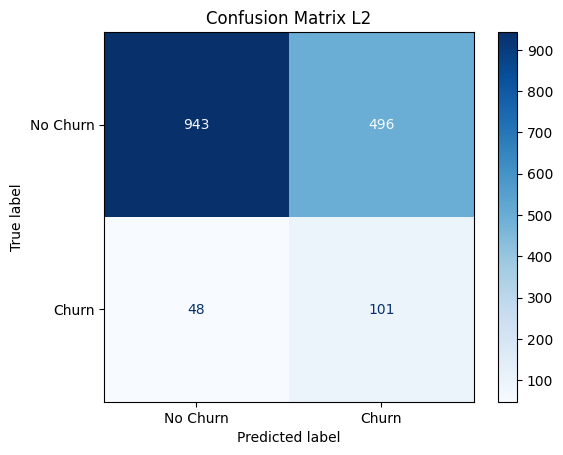

In [32]:
# Display confusion matrix L2
conf_matrix_L2 = confusion_matrix(y_test, y_pred_L2)
disp_L2 = ConfusionMatrixDisplay(conf_matrix_L2, display_labels=['No Churn','Churn'])
disp_L2.plot(cmap='Blues')
plt.title('Confusion Matrix L2')
plt.show()

In [33]:
# Values for false positive (fp_L2), false negative (fn_L2), true positive (tp_L2) and true negative (tn_L2)
fp_L2 = conf_matrix_L2[0][1]
fn_L2 = conf_matrix_L2[1][0]
tp_L2 = conf_matrix_L2[1][1]
tn_L2 = conf_matrix_L2[0][0]

print(f' fp_L2: {fp_L2} \n fn_L2: {fn_L2} \n tp_L2: {tp_L2} \n tn_L2: {tn_L2}')

 fp_L2: 496 
 fn_L2: 48 
 tp_L2: 101 
 tn_L2: 943


In [34]:
# Calculations for accuracy, precision, recall
accuracy_L2 = (tp_L2 + tn_L2)/len(y_test)
precision_L2 = tp_L2/(tp_L2 + fp_L2)
recall_L2 = tp_L2/(tp_L2 + fn_L2)

print(f'Accuracy: {accuracy_L2:.2f}')
print(f'Precision: {precision_L2:.2f}')
print(f'Recall: {recall_L2:.2f}')

Accuracy: 0.66
Precision: 0.17
Recall: 0.68


In [35]:
# Calculate F2 score for Model L2
beta = 2
F2_score_L2 = (1 + beta**2) * (precision_L2 * recall_L2) / (beta**2 * precision_L2 + recall_L2)

print(f'The F2 score for Model L2 is {F2_score_L2:.4f}')

The F2 score for Model L2 is 0.4233


In [36]:
# Profit/loss analysis for Model L2
Profit_Loss_L2 = tp_L2*(L - C) - fp_L2*C - fn_L2*L

print(f'The profit or loss is ${Profit_Loss_L2}')

The profit or loss is $2620


**ROC Curve**     
The ROC Curve plots the True Positive Rate vs False Positive Rate for every possible threshold.     
The higher the AUC (Area Under the Curve) and the more the curve 'bows' toward the top left corner, the better the model is.     

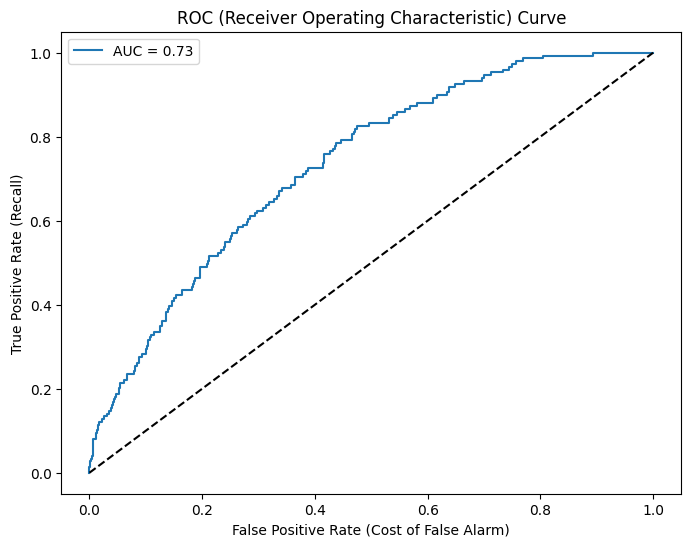

In [37]:
# Plot the ROC Curve
y_probs_L2 = grid_search_L2_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_L2)
auc_L2 = round(roc_auc_score(y_test, y_probs_L2), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_L2):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

**Optimal Threshold**    
The optimal threshold is a careful balance between precision and recall. What threshold to use is a business decision. High precision means money is not wasted on saving customers who are not actually going to leave. High recall means that customers who are about to quit are not missed. However, raising recall lowers precision. Lowering the threshold increases recall but decreases precision.     
_Youden's J Statistic_     
This method to find the optimal threshold from the ROC curve maximizes the vertical distance from the diagonal line or line of random guessing. However, this assumes that the cost of false positive (wrongly flagging a loyal customer might be a churner) is the same as a false negative (missing a customer who is about to churn). For example, if losing a customer costs \$500 and a discount coupon costs only \$40, the threshold should be lowered (move higher on the ROC curve) and move away from the 'Youden point' or optimal threshold.

In [38]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_L2 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_L2:.2f}')

The optimal threshold is 0.41


**Precision-Recall Curve**   
The Precision-Recall Curve shows how precision suffers with the increase in recall. The Average Precision (AP = 0.24) showed that while the model has some predictive power, it struggles with a high number of false positives when trying to catch most churners.

In [39]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_L2)
avg_precision = average_precision_score(y_test, y_probs_L2)

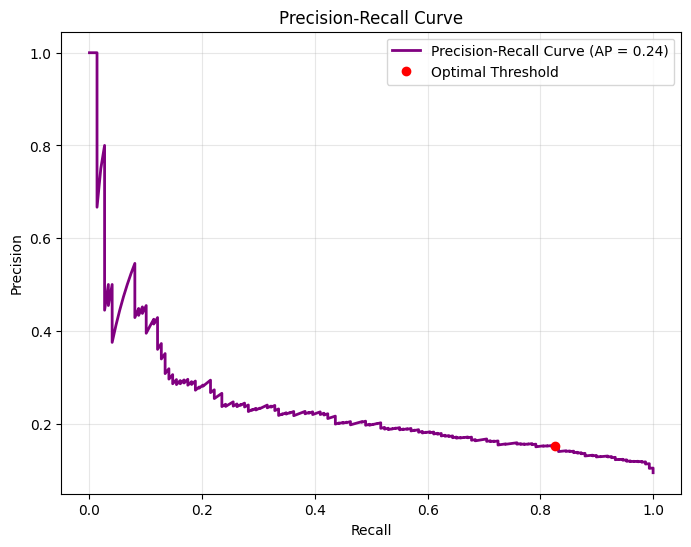

In [40]:
# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_L2))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

**Evaluate precision and recall at different thresholds**     
As shown below, recall improves when threshold is lowered to the best threshold.

In [41]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.70, 0.05)

for threshold in thresholds:
    preds = (y_probs_L2 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=1.00
Threshold=0.15 | Precision=0.10 | Recall=1.00
Threshold=0.20 | Precision=0.11 | Recall=0.99
Threshold=0.25 | Precision=0.12 | Recall=0.97
Threshold=0.30 | Precision=0.13 | Recall=0.93
Threshold=0.35 | Precision=0.14 | Recall=0.88
Threshold=0.40 | Precision=0.15 | Recall=0.83
Threshold=0.45 | Precision=0.16 | Recall=0.76
Threshold=0.50 | Precision=0.17 | Recall=0.68
Threshold=0.55 | Precision=0.18 | Recall=0.58
Threshold=0.60 | Precision=0.20 | Recall=0.49
Threshold=0.65 | Precision=0.22 | Recall=0.42


**Threshold that maximizes profit**     
Given the lifetime value of the subscription (L) and the cost of acquiring the subscription (C), the threshold that maximizes profit is determined.

In [42]:
# Determine the threshold that maximizes profit given L(lifetime value) and C(cost of subscription)
profits = []

for t in thresholds:
    y_pred = (y_probs_L2 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold: .2f}')

The threshold that maximizes profit is  0.25


**Model L3** uses the best threshold.

In [43]:
# Define Model L3 threshold
threshold_L3 = best_threshold

In [44]:
# Use best_threshold to improve recall
y_pred_L3 = (y_probs_L2 >= threshold_L3).astype(int)

In [45]:
# Generate classification report L3

print(classification_report(y_test, y_pred_L3))

              precision    recall  f1-score   support

           0       0.99      0.24      0.39      1439
           1       0.12      0.97      0.21       149

    accuracy                           0.31      1588
   macro avg       0.55      0.61      0.30      1588
weighted avg       0.91      0.31      0.37      1588



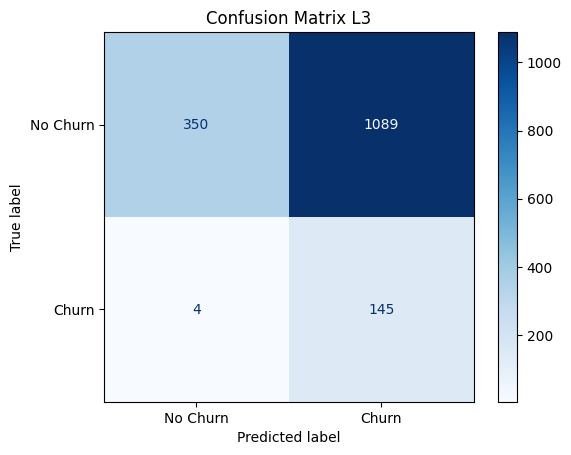

In [46]:
# Display confusion matrix L3
conf_matrix_L3 = confusion_matrix(y_test, y_pred_L3)
disp_L3 = ConfusionMatrixDisplay(conf_matrix_L3, display_labels=['No Churn','Churn'])
disp_L3.plot(cmap='Blues')
plt.title('Confusion Matrix L3')
plt.show()

In [47]:
# Values for false positive (fp_L3), false negative (fn_L3), true positive (tp_L3) and true negative (tn_L3)
fp_L3 = conf_matrix_L3[0][1]
fn_L3 = conf_matrix_L3[1][0]
tp_L3 = conf_matrix_L3[1][1]
tn_L3 = conf_matrix_L3[0][0]

print(f' fp_L3: {fp_L3} \n fn_L3: {fn_L3} \n tp_L3: {tp_L3} \n tn_L3: {tn_L3}')

 fp_L3: 1089 
 fn_L3: 4 
 tp_L3: 145 
 tn_L3: 350


In [48]:
# Calculations for accuracy, precision, recall
accuracy_L3 = (tp_L3 + tn_L3)/len(y_test)
precision_L3 = tp_L3/(tp_L3 + fp_L3)
recall_L3 = tp_L3/(tp_L3 + fn_L3)

print(f'Accuracy_L3: {accuracy_L3:.2f}')
print(f'Precision_L3: {precision_L3:.2f}')
print(f'Recall_L3: {recall_L3:.2f}')
print(f'-'*18)

Accuracy_L3: 0.31
Precision_L3: 0.12
Recall_L3: 0.97
------------------


In [49]:
# Calculate F2 score for Model L3
beta = 2
F2_score_L3 = (1 + beta**2) * (precision_L3 * recall_L3) / (beta**2 * precision_L3 + recall_L3)

print(f'The F2 score for Model L3 is {F2_score_L3:.4f}')

The F2 score for Model L3 is 0.3962


In [50]:
# Profit/loss analysis for Model L3
Profit_Loss_L3 = tp_L3*(L - C) - fp_L3*C - fn_L3*L

print(f'The profit or loss is ${Profit_Loss_L3}')

The profit or loss is $21140


**Features Importance Model L3**     
In descending order, **csat_score**, **tenure_months**, **monthly_logins**, and **payment_failures**	are highly important.

In [51]:
# Extract feature names
feature_names = grid_search_L2_opt.named_steps["transformer"].get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # clean names

print(f'The feature names are: \n \n {feature_names} \n')
print(f'There are {len(feature_names)} feature names.')

The feature names are: 
 
 ['contract_type', 'survey_response', 'gender_Male', 'country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Referral', 'signup_channel_Web', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'tenure_fee_interaction'] 

There are 44 feature names.


In [52]:
# Extract coefficients
coefficients = grid_search_L2_opt.named_steps['lgr'].coef_[0]

print(f'The coefficients are: \n \n {coefficients} \n')
print(f'There are {len(coefficients)} coefficients.')

The coefficients are: 
 
 [-7.16335802e-02 -8.25064805e-02  5.81250521e-02  7.68934475e-02
  6.13830591e-02  2.72537876e-01 -2.28796525e-02  2.08499936e-01
  9.45653456e-02  1.93642773e-02 -3.58899650e-03 -1.12240532e-01
  1.03712280e-02  1.80027175e-02  1.79302419e-01  1.00526563e-01
  1.46214518e-01  9.66316669e-02 -1.09005056e-01  1.02594629e-01
 -6.78016598e-02 -2.70784462e-02 -1.20719505e-01 -1.16291370e-01
  3.17883467e-03  9.86874977e-02 -5.08832795e-01 -4.40969608e-01
  2.70606792e-02 -1.38329375e-02 -4.50571369e-04 -4.36568069e-02
 -2.46149034e-02 -6.79274009e-02  3.88142168e-01  6.92537059e-03
 -3.37069088e-02 -5.47796826e-01  5.19777536e-02  5.69043216e-02
  1.05248869e-02  9.93402602e-03 -2.24008803e-02 -3.83573427e-02] 

There are 44 coefficients.


In [53]:
# Construct a dataframe of coefficients
L3_weight_coef_df = pd.DataFrame({'feature': feature_names, 'coefs': coefficients})
L3_weight_coef_df = L3_weight_coef_df.sort_values(by='coefs', ascending=False)

print(L3_weight_coef_df.head(10))

                        feature     coefs
34             payment_failures  0.388142
5               country_Germany  0.272538
7                    country_UK  0.208500
14                 city_Toronto  0.179302
16         customer_segment_SME  0.146215
19          payment_method_Card  0.102595
15  customer_segment_Individual  0.100527
25                          age  0.098687
17      signup_channel_Referral  0.096632
8                   country_USA  0.094565


In [54]:
# Extract the list of selected features and coefficients for plotting
feature1 = L3_weight_coef_df.iloc[:9,0]
feature2 = L3_weight_coef_df.iloc[-8:,0]
features = pd.concat([feature1, feature2])
features = pd.DataFrame(features)
features_list = features.values.tolist()
features_list = [item for sublist in features_list for item in sublist]

coef1 = L3_weight_coef_df.iloc[:9,1]
coef2 = L3_weight_coef_df.iloc[-8:,1]
coefs = pd.concat([coef1, coef2])
coefs = pd.DataFrame(coefs)
coefs_list = coefs.values.tolist()
coefs_list = [item for sublist in coefs_list for item in sublist]

In [55]:
# Prepare to plot the important features and coefficients

plot_data_lgr = {
    'feature': features_list,
    'coefs': coefs_list
}

plot_lgr_df = pd.DataFrame(plot_data_lgr)
plot_lgr_df = plot_lgr_df.sort_values(by='coefs', ascending=True)

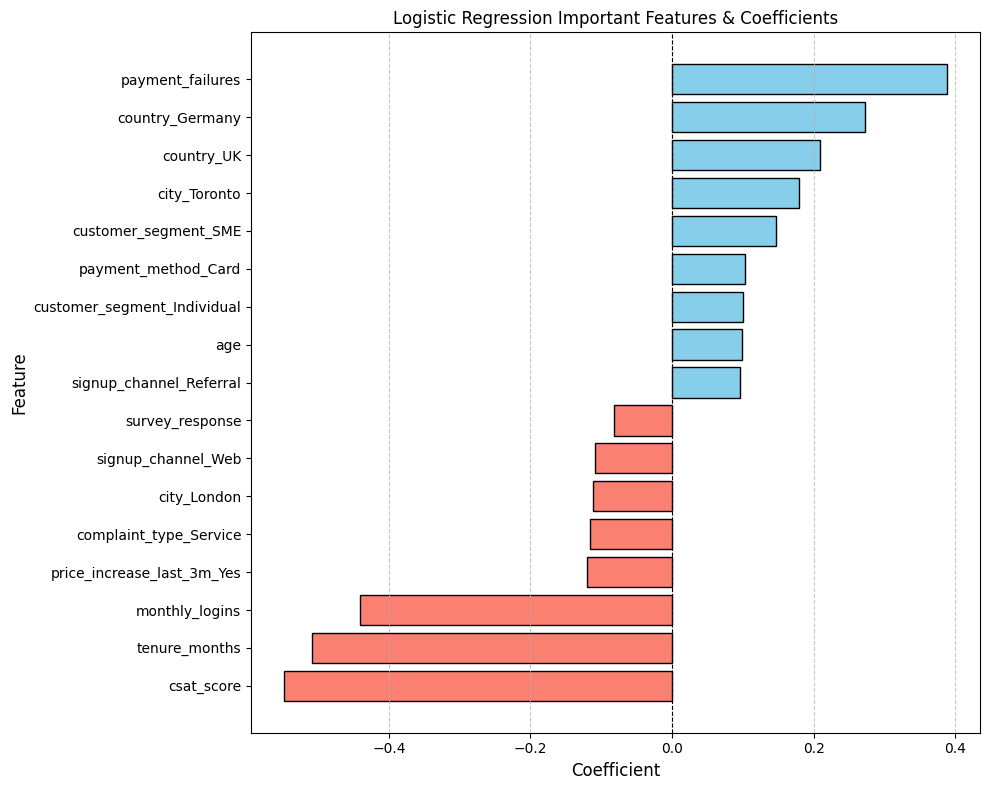

In [56]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in plot_lgr_df['coefs']]
plt.barh(plot_lgr_df['feature'], plot_lgr_df['coefs'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Important Features & Coefficients')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Churn Odds**    
**payment failures** is the number one predictor for churn. A customer with failed payments is significantly more likely to leave. A unit increase in payment failures raises odds of churn by **percent_change** assuming all other variables remain constant.         
As these values go up, the probability of churn increases.  

On the other hand, **csat score** is the number one retention factor. High customer satisfaction is the strongest signal that a customer will stay. A unit increase in customer satisfaction scores decreases odds of churn by **percent_change** assuming all other variables remain constant.
  
**tenure months** is another anchor - the longer a customer stays, the less likely it is to leave.   

**monthly logins** - high product engagement is a major indicator of a healthy customer who will continue to stay.         
As these values go up, the probability of churn decreases.


In [57]:
# Calculate odds ratios and percentage change in odds
L3_weight_coef_df['odds_ratio'] = np.exp(L3_weight_coef_df['coefs'])
L3_weight_coef_df['percent_change'] = (L3_weight_coef_df['odds_ratio'] - 1) * 100

# Sort by coefficient
L3_weight_coef_df = L3_weight_coef_df.sort_values(by='coefs', ascending=False)
L3_weight_coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
34,payment_failures,0.388142,1.474239,47.423936
5,country_Germany,0.272538,1.313293,31.329320
7,country_UK,0.208500,1.231829,23.182885
14,city_Toronto,0.179302,1.196382,19.638250
16,customer_segment_SME,0.146215,1.157444,15.744445
19,payment_method_Card,0.102595,1.108042,10.804215
15,customer_segment_Individual,0.100527,1.105753,10.575301
25,age,0.098687,1.103721,10.372133
17,signup_channel_Referral,0.096632,1.101455,10.145460
8,country_USA,0.094565,1.099181,9.918099


In [58]:
# Sort by coefs absolute values
L3_weight_coef_df['coefs'] = L3_weight_coef_df['coefs'].apply(abs)
L3_weight_coef_df = L3_weight_coef_df.sort_values(by = 'coefs', ascending = False)

L3_weight_coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
37,csat_score,0.547797,0.578222,-42.177767
26,tenure_months,0.508833,0.601197,-39.880311
27,monthly_logins,0.440970,0.643412,-35.658774
34,payment_failures,0.388142,1.474239,47.423936
5,country_Germany,0.272538,1.313293,31.329320
7,country_UK,0.208500,1.231829,23.182885
14,city_Toronto,0.179302,1.196382,19.638250
16,customer_segment_SME,0.146215,1.157444,15.744445
22,price_increase_last_3m_Yes,0.120720,0.886283,-11.371748
23,complaint_type_Service,0.116291,0.890216,-10.978420


In [59]:
# Reset index
L3_weight_coef_df = L3_weight_coef_df.reset_index(drop=True)
L3_weight_coef_df.index = L3_weight_coef_df.index + 1
L3_weight_coef_df.index.name = "Rank"

L3_weight_coef_df.head(10)

,feature,coefs,odds_ratio,percent_change
Rank,,,,
1,csat_score,0.547797,0.578222,-42.177767
2,tenure_months,0.508833,0.601197,-39.880311
3,monthly_logins,0.440970,0.643412,-35.658774
4,payment_failures,0.388142,1.474239,47.423936
5,country_Germany,0.272538,1.313293,31.329320
6,country_UK,0.208500,1.231829,23.182885
7,city_Toronto,0.179302,1.196382,19.638250
8,customer_segment_SME,0.146215,1.157444,15.744445
9,price_increase_last_3m_Yes,0.120720,0.886283,-11.371748


**Sequential Feature Selection**     

Feature selection reduces noise and improves the interpretation of feature importance.
    
Feature selection is about removing noise, improving interpretability, improving logistic regression stability, and slightly reducing overfitting.

**Model L4** uses Sequential Feature Selection

In [60]:
# Define the classifier
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000)

In [61]:
# Instantiate Sequential Feature Selector
sfs = SequentialFeatureSelector(
    log_reg,
    n_features_to_select="auto",
    direction="forward",
    scoring="f1",
    cv=3
)

In [62]:
# Build pipeline including sequential feature selection
lgr_pipe_L4 = Pipeline([
    ('transformer', transformer),
    ("sfs", sfs),
    ('lgr', log_reg)
])
lgr_pipe_L4.fit(X_train, y_train)
lgr_pipe_L4

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('sfs',
                 SequentialFeatureSelector(cv=3,
                                           estimator=LogisticRegression(class_weight='balanced',
                                                                        max_iter=3000,
                                                                        random_state=42),
                                           scoring='f1')),
                ('lgr',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

In [63]:
# Define parameter grid
param_grid_L4 = {
    'lgr__penalty': ['l1','l2'],
    'lgr__solver': ['saga'],
    'lgr__C': np.logspace(-3,3,8)
}

In [64]:
# Run HalvingRandomSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_L4 = HalvingRandomSearchCV(lgr_pipe_L4, param_grid_L4, cv=cv, scoring='f1', n_jobs=-1)
grid_search_L4.fit(X_train, y_train)

print(f'Best parameters: {grid_search_L4.best_params_}')
print(f'Best score: {grid_search_L4.best_score_:.4f}')

Best parameters: {'lgr__solver': 'saga', 'lgr__penalty': 'l1', 'lgr__C': np.float64(19.306977288832496)}
Best score: 0.1352


In [65]:
# Get the best model from the grid search and selected features
grid_search_L4_opt = grid_search_L4.best_estimator_
feature_names = grid_search_L4_opt.named_steps['transformer'].get_feature_names_out()
mask = grid_search_L4_opt.named_steps['sfs'].get_support()
selected_features = feature_names[mask]
selected_features = [name.split('__')[1] for name in selected_features]   # Clean the feature names

print(selected_features, '\n')
print(f'There are {len(selected_features)} selected features.')

['contract_type', 'country_Bangladesh', 'country_Canada', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'signup_channel_Web', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'tenure_months', 'monthly_logins', 'usage_growth_rate', 'last_login_days_ago', 'payment_failures', 'avg_resolution_time', 'csat_score'] 

There are 22 selected features.


In [66]:
# Generate classification report L4
y_pred_L4 = grid_search_L4_opt.predict(X_test)

print(classification_report(y_test, y_pred_L4))

              precision    recall  f1-score   support

           0       0.95      0.65      0.77      1439
           1       0.17      0.68      0.27       149

    accuracy                           0.65      1588
   macro avg       0.56      0.66      0.52      1588
weighted avg       0.88      0.65      0.72      1588



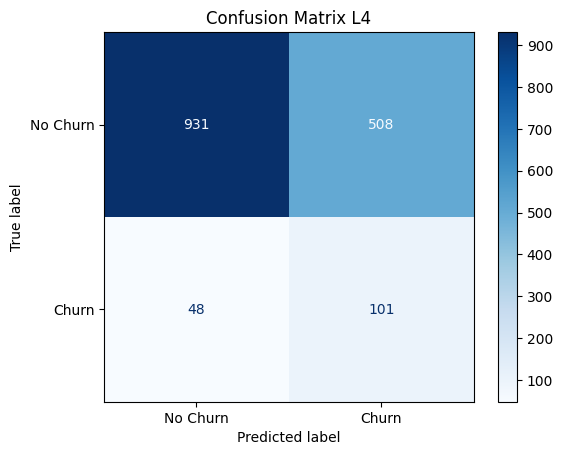

In [67]:
# Display confusion matrix L4
conf_matrix_L4 = confusion_matrix(y_test, y_pred_L4)
disp_L4 = ConfusionMatrixDisplay(conf_matrix_L4, display_labels=['No Churn','Churn'])
disp_L4.plot(cmap='Blues')
plt.title('Confusion Matrix L4')
plt.show()

In [68]:
# Values for false positive (fp_L4), false negative (fn_L4), true positive (tp_L4) and true negative (tn_L4)
fp_L4 = conf_matrix_L4[0][1]
fn_L4 = conf_matrix_L4[1][0]
tp_L4 = conf_matrix_L4[1][1]
tn_L4 = conf_matrix_L4[0][0]

print(f' fp_L4: {fp_L4} \n fn_L4: {fn_L4} \n tp_L4: {tp_L4} \n tn_L4: {tn_L4}')

 fp_L4: 508 
 fn_L4: 48 
 tp_L4: 101 
 tn_L4: 931


In [69]:
# Calculations for accuracy, precision, recall
accuracy_L4 = (tp_L4 + tn_L4)/len(y_test)
precision_L4 = tp_L4/(tp_L4 + fp_L4)
recall_L4 = tp_L4/(tp_L4 + fn_L4)

print(f'Accuracy_L4: {accuracy_L4:.2f}')
print(f'Precision_L4: {precision_L4:.2f}')
print(f'Recall_L4: {recall_L4:.2f}')
print(f'-'*18)

Accuracy_L4: 0.65
Precision_L4: 0.17
Recall_L4: 0.68
------------------


In [70]:
# Calculate F2 score for Model L4
beta = 2
F2_score_L4 = (1 + beta**2) * (precision_L4 * recall_L4) / (beta**2 * precision_L4 + recall_L4)

print(f'The F2 score for Model L4 is {F2_score_L4:.4f}')

The F2 score for Model L4 is 0.4191


In [71]:
# Profit/loss analysis for Model L4
Profit_Loss_L4 = tp_L4*(L - C) - fp_L4*C - fn_L4*L

print(f'The profit or loss is ${Profit_Loss_L4}')

The profit or loss is $2140


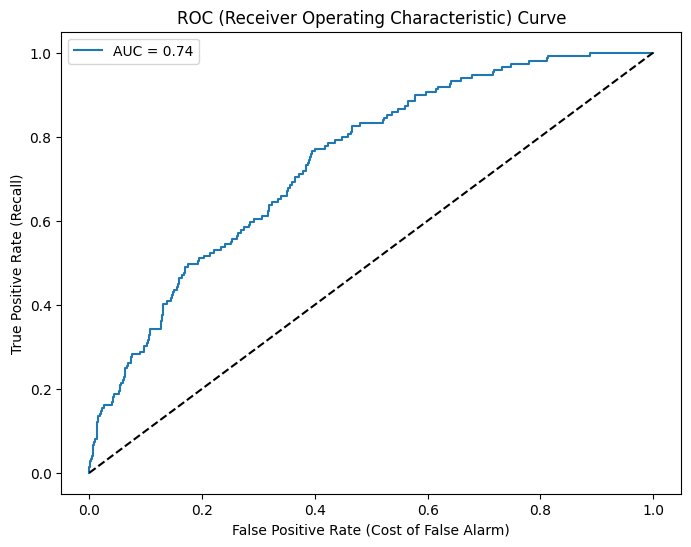

In [72]:
# Plot the ROC Curve
y_probs_L4 = grid_search_L4_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_L4)
auc_L4 = round(roc_auc_score(y_test, y_probs_L4), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_L4):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [73]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_L4 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_L4:.2f}')

The optimal threshold is 0.47


In [74]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_L4)
avg_precision = average_precision_score(y_test, y_probs_L4)

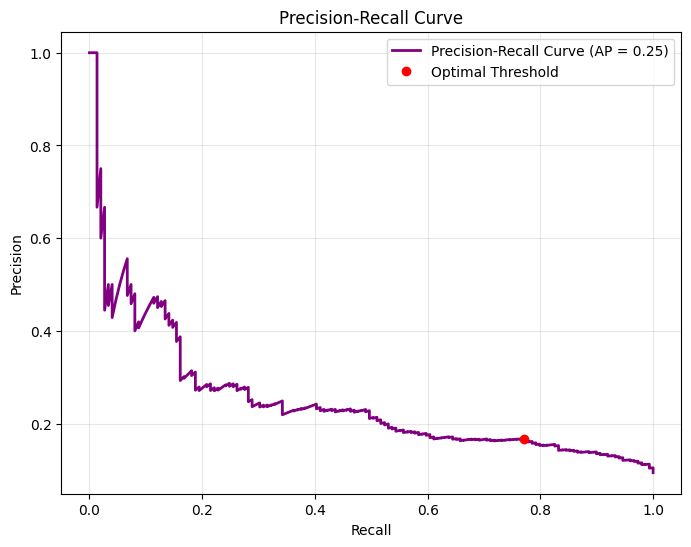

In [75]:
# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_L4))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [76]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.70, 0.05)

for threshold in thresholds:
    preds = (y_probs_L4 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=1.00
Threshold=0.15 | Precision=0.10 | Recall=1.00
Threshold=0.20 | Precision=0.11 | Recall=0.99
Threshold=0.25 | Precision=0.12 | Recall=0.97
Threshold=0.30 | Precision=0.12 | Recall=0.95
Threshold=0.35 | Precision=0.14 | Recall=0.91
Threshold=0.40 | Precision=0.15 | Recall=0.83
Threshold=0.45 | Precision=0.16 | Recall=0.79
Threshold=0.50 | Precision=0.17 | Recall=0.68
Threshold=0.55 | Precision=0.18 | Recall=0.58
Threshold=0.60 | Precision=0.21 | Recall=0.52
Threshold=0.65 | Precision=0.23 | Recall=0.42


In [77]:
# Determine the threshold that maximizes profit given L(lifetime value) and C(cost of subscription)
profits = []

for t in thresholds:
    y_pred = (y_probs_L4 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold:.2f}')

The threshold that maximizes profit is 0.30


In [78]:
# Define Model L4 threshold
threshold_L4 = best_threshold

In [79]:
# Use best_threshold to improve recall
y_pred_L4 = (y_probs_L4 >= threshold_L4).astype(int)

In [80]:
# Generate classification report L4

print(classification_report(y_test, y_pred_L4))

              precision    recall  f1-score   support

           0       0.98      0.31      0.47      1439
           1       0.12      0.95      0.22       149

    accuracy                           0.37      1588
   macro avg       0.55      0.63      0.34      1588
weighted avg       0.90      0.37      0.44      1588



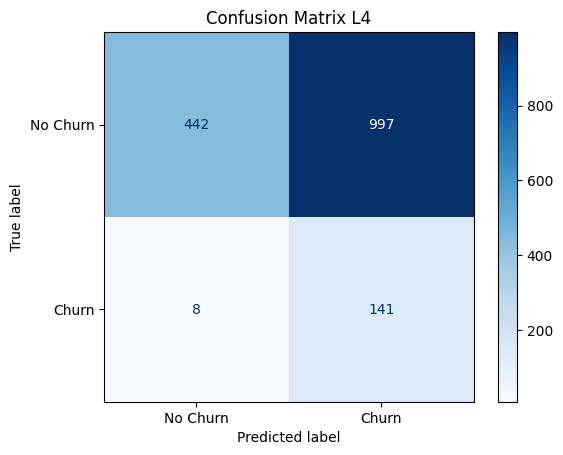

In [81]:
# Display confusion matrix L4
conf_matrix_L4 = confusion_matrix(y_test, y_pred_L4)
disp_L4 = ConfusionMatrixDisplay(conf_matrix_L4, display_labels=['No Churn','Churn'])
disp_L4.plot(cmap='Blues')
plt.title('Confusion Matrix L4')
plt.show()

In [82]:
# Values for false positive (fp_L4), false negative (fn_L4), true positive (tp_L4) and true negative (tn_L4)
fp_L4 = conf_matrix_L4[0][1]
fn_L4 = conf_matrix_L4[1][0]
tp_L4 = conf_matrix_L4[1][1]
tn_L4 = conf_matrix_L4[0][0]

print(f' fp_L4: {fp_L4} \n fn_L4: {fn_L4} \n tp_L4: {tp_L4} \n tn_L4: {tn_L4}')

 fp_L4: 997 
 fn_L4: 8 
 tp_L4: 141 
 tn_L4: 442


In [83]:
# Calculations for accuracy, precision, recall
accuracy_L4 = (tp_L4 + tn_L4)/len(y_test)
precision_L4 = tp_L4/(tp_L4 + fp_L4)
recall_L4 = tp_L4/(tp_L4 + fn_L4)

print(f'Accuracy_L4: {accuracy_L4:.2f}')
print(f'Precision_L4: {precision_L4:.2f}')
print(f'Recall_L4: {recall_L4:.2f}')
print(f'-'*18)

Accuracy_L4: 0.37
Precision_L4: 0.12
Recall_L4: 0.95
------------------


In [84]:
# Calculate F2 score for Model L4
beta = 2
F2_score_L4 = (1 + beta**2) * (precision_L4 * recall_L4) / (beta**2 * precision_L4 + recall_L4)

print(f'The F2 score for Model L4 is {F2_score_L4:.4f}')

The F2 score for Model L4 is 0.4066


In [85]:
# Profit/loss analysis for Model L4
Profit_Loss_L4 = tp_L4*(L - C) - fp_L4*C - fn_L4*L

print(f'The profit or loss is ${Profit_Loss_L4}')

The profit or loss is $20980


**Features Importance Model L4**     
In descending order, **csat_score**, **tenure_months**, **monthly_logins**, and **payment_failures**	are highly important.

In [86]:
# Extract feature names
feature_names = grid_search_L4_opt.named_steps["transformer"].get_feature_names_out()

print(f'The feature names are: \n \n {feature_names} \n')
print(f'There are {len(feature_names)} feature names.')

The feature names are: 
 
 ['ordinalencoder__contract_type' 'ordinalencoder__survey_response'
 'onehotencoder__gender_Male' 'onehotencoder__country_Bangladesh'
 'onehotencoder__country_Canada' 'onehotencoder__country_Germany'
 'onehotencoder__country_India' 'onehotencoder__country_UK'
 'onehotencoder__country_USA' 'onehotencoder__city_Delhi'
 'onehotencoder__city_Dhaka' 'onehotencoder__city_London'
 'onehotencoder__city_New York' 'onehotencoder__city_Sydney'
 'onehotencoder__city_Toronto'
 'onehotencoder__customer_segment_Individual'
 'onehotencoder__customer_segment_SME'
 'onehotencoder__signup_channel_Referral'
 'onehotencoder__signup_channel_Web' 'onehotencoder__payment_method_Card'
 'onehotencoder__payment_method_PayPal'
 'onehotencoder__discount_applied_Yes'
 'onehotencoder__price_increase_last_3m_Yes'
 'onehotencoder__complaint_type_Service'
 'onehotencoder__complaint_type_Technical' 'remainder__age'
 'remainder__tenure_months' 'remainder__monthly_logins'
 'remainder__weekly_acti

In [87]:
# Extract selected features
selector = grid_search_L4_opt.named_steps["sfs"]
mask = selector.get_support()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # clean names

print(f'The selected features are: \n \n {selected_features} \n')
print(f'There are {len(selected_features)} selected feature.')

The selected features are: 
 
 ['contract_type', 'country_Bangladesh', 'country_Canada', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'signup_channel_Web', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'tenure_months', 'monthly_logins', 'usage_growth_rate', 'last_login_days_ago', 'payment_failures', 'avg_resolution_time', 'csat_score'] 

There are 22 selected feature.


In [88]:
# Extract coefficients
coefficients = grid_search_L4_opt.named_steps['lgr'].coef_[0]

print(f'The coefficients are: \n \n {coefficients} \n')
print(f'There are {len(coefficients)} coefficients.')

The coefficients are: 
 
 [-0.08230646 -0.02599069 -0.06778625  0.03690093  0.00621821 -0.11168443
  0.01137106  0.02406446  0.18405567 -0.15279619 -0.12814577 -0.03752606
 -0.11201255 -0.09259894  0.00911719 -0.52075878 -0.43697735 -0.04127779
 -0.02336588  0.38982515 -0.0446136  -0.5450831 ] 

There are 22 coefficients.


In [89]:
# Construct a dataframe of coefficients
L4_weight_coef_df = pd.DataFrame({'feature': selected_features, 'coefs': coefficients})
L4_weight_coef_df = L4_weight_coef_df.sort_values(by='coefs', ascending=False)

print(L4_weight_coef_df.head(10))

                     feature     coefs
19          payment_failures  0.389825
8               city_Toronto  0.184056
3                 city_Delhi  0.036901
7                city_Sydney  0.024064
6              city_New York  0.011371
14  complaint_type_Technical  0.009117
4                 city_Dhaka  0.006218
18       last_login_days_ago -0.023366
1         country_Bangladesh -0.025991
11      discount_applied_Yes -0.037526


In [90]:
# Extract the list of selected features and coefficients for plotting
feature1 = L4_weight_coef_df.iloc[:9,0]
feature2 = L4_weight_coef_df.iloc[-8:,0]
features = pd.concat([feature1, feature2])
features = pd.DataFrame(features)
features_list = features.values.tolist()
features_list = [item for sublist in features_list for item in sublist]

coef1 = L4_weight_coef_df.iloc[:9,1]
coef2 = L4_weight_coef_df.iloc[-8:,1]
coefs = pd.concat([coef1, coef2])
coefs = pd.DataFrame(coefs)
coefs_list = coefs.values.tolist()
coefs_list = [item for sublist in coefs_list for item in sublist]

In [91]:
# Prepare to plot the important features and coefficients

plot_data_lgr = {
    'feature': features_list,
    'coefs': coefs_list
}

plot_lgr_df = pd.DataFrame(plot_data_lgr)
plot_lgr_df = plot_lgr_df.sort_values(by='coefs', ascending=True)

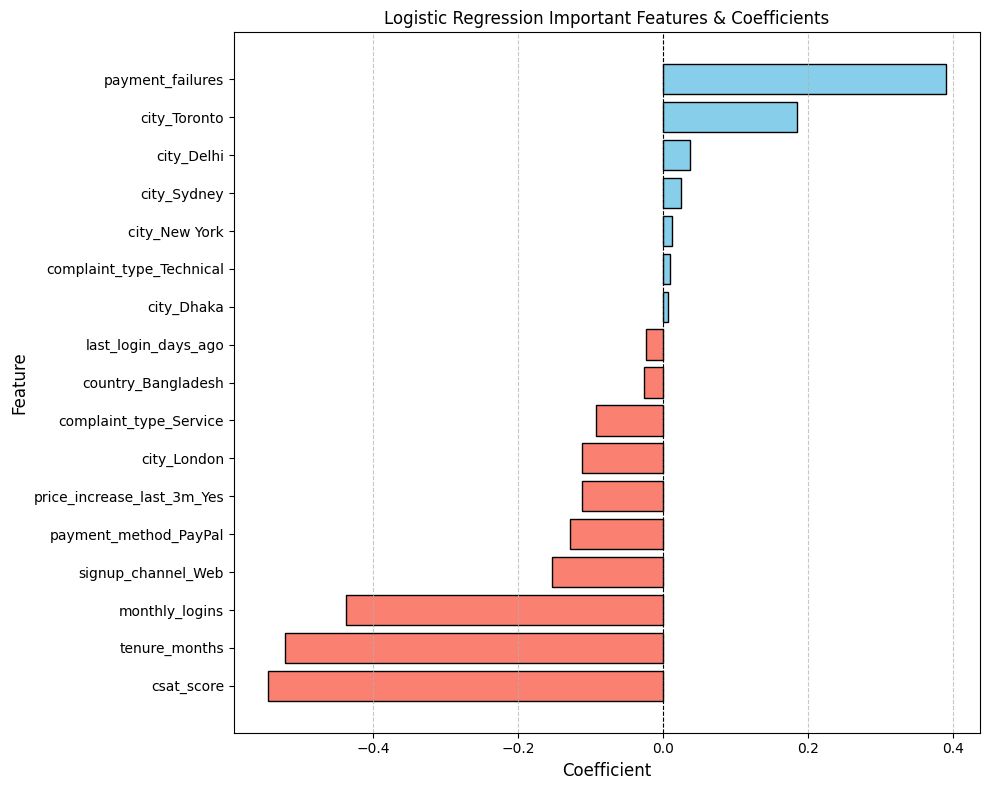

In [92]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in plot_lgr_df['coefs']]
plt.barh(plot_lgr_df['feature'], plot_lgr_df['coefs'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Important Features & Coefficients')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Churn Odds**    
**payment failures** is the number one predictor for churn. A customer with failed payments is significantly more likely to leave. A unit increase in payment failures raises odds of churn by **percent_change** assuming all other variables remain constant.         
As these values go up, the probability of churn increases.  

On the other hand, **csat score** is the number one retention factor. High customer satisfaction is the strongest signal that a customer will stay. A unit increase in customer satisfaction scores decreases odds of churn by **percent_change** assuming all other variables remain constant.

**tenure months** is another anchor - the longer a customer stays, the less likely it is to leave.

**monthly logins** - high product engagement is a major indicator of a healthy customer who will continue to stay.    
          
As these values go up, the probability of churn decreases.

In [93]:
# Calculate odds ratios and percentage change in odds
L4_weight_coef_df['odds_ratio'] = np.exp(L4_weight_coef_df['coefs'])
L4_weight_coef_df['percent_change'] = (L4_weight_coef_df['odds_ratio'] - 1) * 100

# Sort by coefficient
L4_weight_coef_df = L4_weight_coef_df.sort_values(by='coefs', ascending=False)
L4_weight_coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
19,payment_failures,0.389825,1.476723,47.672257
8,city_Toronto,0.184056,1.202083,20.208274
3,city_Delhi,0.036901,1.037590,3.759022
7,city_Sydney,0.024064,1.024356,2.435635
6,city_New York,0.011371,1.011436,1.143596
14,complaint_type_Technical,0.009117,1.009159,0.915888
4,city_Dhaka,0.006218,1.006238,0.623759
18,last_login_days_ago,-0.023366,0.976905,-2.309501
1,country_Bangladesh,-0.025991,0.974344,-2.565584
11,discount_applied_Yes,-0.037526,0.963169,-3.683068


In [94]:
# Sort by coefs absolute values
L4_weight_coef_df['coefs'] = L4_weight_coef_df['coefs'].apply(abs)
L4_weight_coef_df = L4_weight_coef_df.sort_values(by = 'coefs', ascending = False)

L4_weight_coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
21,csat_score,0.545083,0.579794,-42.020640
15,tenure_months,0.520759,0.594070,-40.593039
16,monthly_logins,0.436977,0.645986,-35.401394
19,payment_failures,0.389825,1.476723,47.672257
8,city_Toronto,0.184056,1.202083,20.208274
9,signup_channel_Web,0.152796,0.858305,-14.169537
10,payment_method_PayPal,0.128146,0.879725,-12.027486
12,price_increase_last_3m_Yes,0.112013,0.894033,-10.596696
5,city_London,0.111684,0.894326,-10.567357
13,complaint_type_Service,0.092599,0.911559,-8.844098


In [95]:
# Reset index
L4_weight_coef_df = L4_weight_coef_df.reset_index(drop=True)
L4_weight_coef_df.index = L4_weight_coef_df.index + 1
L4_weight_coef_df.index.name = "Rank"

L4_weight_coef_df.head(10)

,feature,coefs,odds_ratio,percent_change
Rank,,,,
1,csat_score,0.545083,0.579794,-42.020640
2,tenure_months,0.520759,0.594070,-40.593039
3,monthly_logins,0.436977,0.645986,-35.401394
4,payment_failures,0.389825,1.476723,47.672257
5,city_Toronto,0.184056,1.202083,20.208274
6,signup_channel_Web,0.152796,0.858305,-14.169537
7,payment_method_PayPal,0.128146,0.879725,-12.027486
8,price_increase_last_3m_Yes,0.112013,0.894033,-10.596696
9,city_London,0.111684,0.894326,-10.567357


**Model L5** uses Random Forest Classifier for feature selection.     

Random Forest Classifier is used to select the top features. The model is retrained using these features. Random Forest Classifier is good for ranking features. It handles nonlinearity, interactions, and correlations quite well.

In [96]:
# Obtain the best number of features based on the maximum AUC
auc=[]
features = np.arange(36, 42, 2)
for i in features:
  # Build the pipeline
  lgr_pipe = Pipeline([
      ("transformer", transformer),
      ("feature_selection", SelectFromModel(RandomForestClassifier(random_state=42), max_features=i,
          threshold=-float("inf"))),   # ensures exactly the number of features
      ("lgr", LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000))
  ])
  lgr_pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
      'lgr__C': np.logspace(-3,3,8),
      'lgr__penalty': ['l1', 'l2'],
      'lgr__solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga']
  }
  # Run RandomizedSearchCV
  grid_search = HalvingRandomSearchCV(lgr_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
  grid_search.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_search_opt = grid_search.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_search_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 36 | AUC = 0.7322
Number of Features = 38 | AUC = 0.7379
Number of Features = 40 | AUC = 0.7344


In [97]:
# Extract the best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 38.


In [98]:
# Build the pipeline using the best features
lgr_pipe_L5 = Pipeline([
    ("transformer", transformer),
    ("feature_selection", SelectFromModel(RandomForestClassifier(random_state=42), max_features=best_features,
        threshold=-float("inf"))),
    ("lgr", LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000))
])
lgr_pipe_L5.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(38), threshold=-inf)),
                ('lgr',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

In [99]:
# Define parameter grid
param_grid_L5 = {
    'lgr__C': np.logspace(-3,3,8),
    'lgr__penalty': ['l1', 'l2'],
    'lgr__solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga']
}

In [100]:
# Run HalvingRandomSearchCV
grid_search_L5 = HalvingRandomSearchCV(lgr_pipe_L5, param_grid_L5, cv=5, scoring='f1', n_jobs=-1)
grid_search_L5.fit(X_train, y_train)

print(f'Best parameters: {grid_search_L5.best_params_}')
print(f'Best score: {grid_search_L5.best_score_:.4f}')

Best parameters: {'lgr__solver': 'liblinear', 'lgr__penalty': 'l1', 'lgr__C': np.float64(0.3727593720314938)}
Best score: 0.2396


In [101]:
# Access the optimized pipeline model
grid_search_L5_opt = grid_search_L5.best_estimator_
grid_search_L5_opt

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer...
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(38), threshold=-inf)),
                ('lgr',
                 LogisticRegression(C=np.float64(0.3727593720314938),
                                    class_weight='balanced', max_iter=3000,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [102]:
# Accuracy of model on train and test data
grid_search_L5_opt_acc_train = grid_search_L5_opt.score(X_train, y_train)
grid_search_L5_opt_acc_test = grid_search_L5_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_L5_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_L5_opt_acc_test*100:.2f}%')

The train accuracy of the model is 67.85%
The test accuracy of the model is 65.49%


In [103]:
# Generate classification report
y_pred_L5 = grid_search_L5_opt.predict(X_test)

print(classification_report(y_test, y_pred_L5))

              precision    recall  f1-score   support

           0       0.95      0.66      0.77      1439
           1       0.16      0.65      0.26       149

    accuracy                           0.65      1588
   macro avg       0.56      0.65      0.52      1588
weighted avg       0.87      0.65      0.73      1588



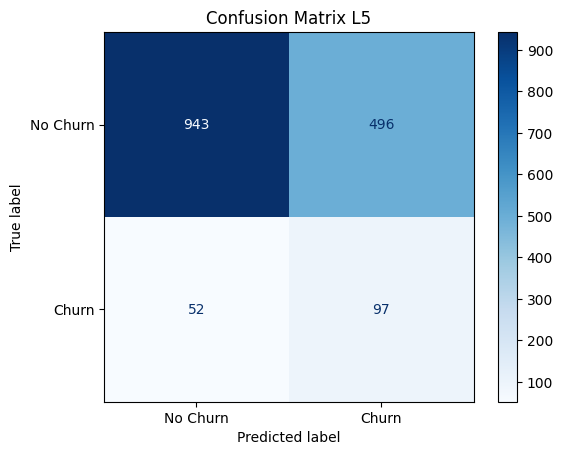

In [104]:
# Display confusion matrix
conf_matrix_L5 = confusion_matrix(y_test, y_pred_L5)
disp_L5 = ConfusionMatrixDisplay(conf_matrix_L5, display_labels=['No Churn','Churn'])
disp_L5.plot(cmap='Blues')
plt.title('Confusion Matrix L5')
plt.show()

In [105]:
# Values for false positive (fp_L5), false negative (fn_L5), true positive (tp_L5) and true negative (tn_L5)
fp_L5 = conf_matrix_L5[0][1]
fn_L5 = conf_matrix_L5[1][0]
tp_L5 = conf_matrix_L5[1][1]
tn_L5 = conf_matrix_L5[0][0]

print(f' fp_L5: {fp_L5} \n fn_L5: {fn_L5} \n tp_L5: {tp_L5} \n tn_L5: {tn_L5}')

 fp_L5: 496 
 fn_L5: 52 
 tp_L5: 97 
 tn_L5: 943


In [106]:
# Calculations for accuracy, precision, recall
accuracy_L5 = (tp_L5 + tn_L5)/len(y_test)
precision_L5 = tp_L5/(tp_L5 + fp_L5)
recall_L5 = tp_L5/(tp_L5 + fn_L5)

print(f'Accuracy: {accuracy_L5:.2f}')
print(f'Precision: {precision_L5:.2f}')
print(f'Recall: {recall_L5:.2f}')
print(f'-'*15)

Accuracy: 0.65
Precision: 0.16
Recall: 0.65
---------------


In [107]:
# Calculate F2 score
beta = 2
F2_score_L5 = (1 + beta**2) * (precision_L5 * recall_L5) / (beta**2 * precision_L5 + recall_L5)

print(f'The F2 score is {F2_score_L5:.4f}')

The F2 score is 0.4079


In [108]:
# Profit/loss analysis
Profit_Loss_L5 = tp_L5*(L - C) - fp_L5*C - fn_L5*L

print(f'The profit or loss is ${Profit_Loss_L5}')

The profit or loss is $-1220


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

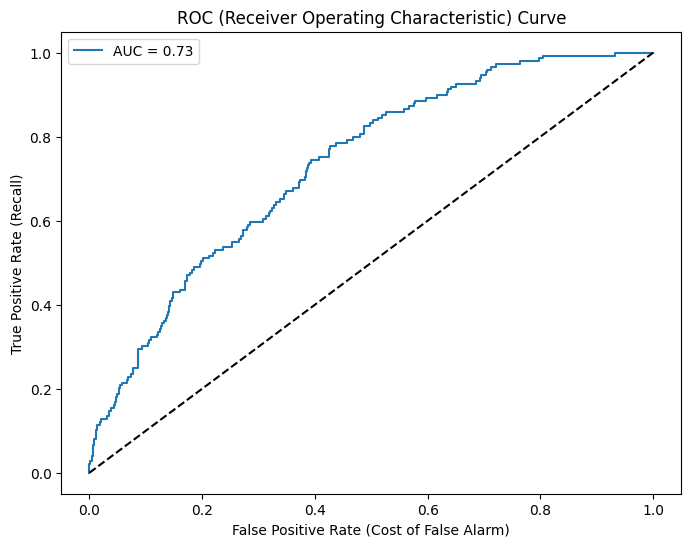

In [109]:
# Plot the ROC Curve
y_probs_L5 = grid_search_L5_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_L5)
auc_L5 = round(roc_auc_score(y_test, y_probs_L5), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_L5):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [110]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_L5 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_L5:.2f}')

The optimal threshold is 0.45


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve.

In [111]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_L5)
avg_precision = average_precision_score(y_test, y_probs_L5)

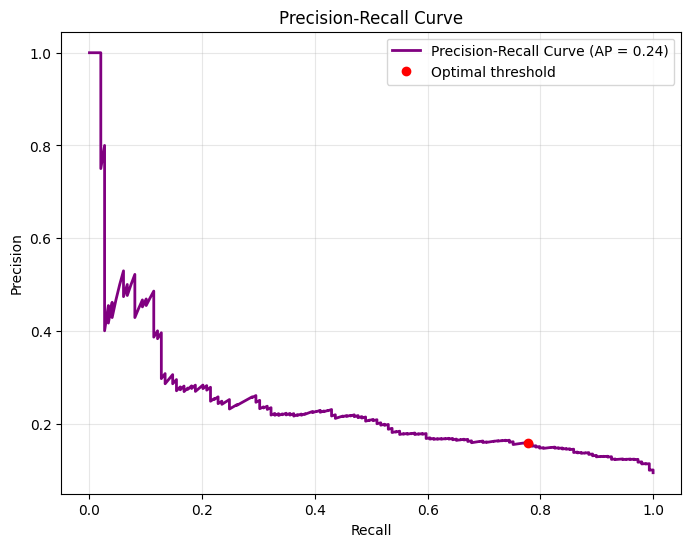

In [112]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_L5))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [113]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_L5 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=1.00
Threshold=0.15 | Precision=0.10 | Recall=0.99
Threshold=0.20 | Precision=0.11 | Recall=0.99
Threshold=0.25 | Precision=0.12 | Recall=0.98
Threshold=0.30 | Precision=0.12 | Recall=0.93
Threshold=0.35 | Precision=0.13 | Recall=0.89
Threshold=0.40 | Precision=0.15 | Recall=0.83
Threshold=0.45 | Precision=0.16 | Recall=0.78
Threshold=0.50 | Precision=0.16 | Recall=0.65
Threshold=0.55 | Precision=0.18 | Recall=0.58
Threshold=0.60 | Precision=0.20 | Recall=0.51
Threshold=0.65 | Precision=0.22 | Recall=0.43
Threshold=0.70 | Precision=0.23 | Recall=0.30
Threshold=0.75 | Precision=0.27 | Recall=0.21


In [114]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_L5 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold: .2f}')

The threshold that maximizes profit is  0.25


In [115]:
# Define Model L5 threshold
threshold_L5 = best_threshold

In [116]:
# Use the threshold that maximizes profit
y_pred_L5 = (y_probs_L5 >= best_threshold).astype(int)

In [117]:
# Generate classification report

print(classification_report(y_test, y_pred_L5))

              precision    recall  f1-score   support

           0       0.99      0.23      0.38      1439
           1       0.12      0.98      0.21       149

    accuracy                           0.30      1588
   macro avg       0.55      0.61      0.29      1588
weighted avg       0.91      0.30      0.36      1588



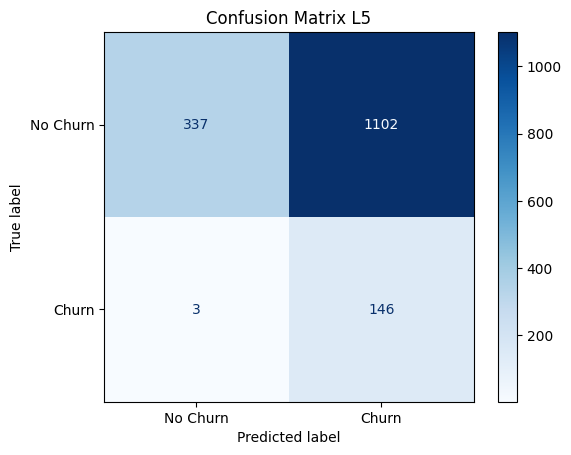

In [118]:
# Display confusion matrix
conf_matrix_L5 = confusion_matrix(y_test, y_pred_L5)
disp_L5 = ConfusionMatrixDisplay(conf_matrix_L5, display_labels=['No Churn','Churn'])
disp_L5.plot(cmap='Blues')
plt.title('Confusion Matrix L5')
plt.show()

In [119]:
# Values for false positive (fp_L5), false negative (fn_L5), true positive (tp_L5) and true negative (tn_L5)
fp_L5 = conf_matrix_L5[0][1]
fn_L5 = conf_matrix_L5[1][0]
tp_L5 = conf_matrix_L5[1][1]
tn_L5 = conf_matrix_L5[0][0]

print(f' fp_L5: {fp_L5} \n fn_L5: {fn_L5} \n tp_L5: {tp_L5} \n tn_L5: {tn_L5}')

 fp_L5: 1102 
 fn_L5: 3 
 tp_L5: 146 
 tn_L5: 337


In [120]:
# Calculations for accuracy, precision, recall
accuracy_L5 = (tp_L5 + tn_L5)/len(y_test)
precision_L5 = tp_L5/(tp_L5 + fp_L5)
recall_L5 = tp_L5/(tp_L5 + fn_L5)

print(f'Accuracy: {accuracy_L5:.2f}')
print(f'Precision: {precision_L5:.2f}')
print(f'Recall: {recall_L5:.2f}')
print(f'-'*15)

Accuracy: 0.30
Precision: 0.12
Recall: 0.98
---------------


In [121]:
# Calculate F2 score
beta = 2
F2_score_L5 = (1 + beta**2) * (precision_L5 * recall_L5) / (beta**2 * precision_L5 + recall_L5)

print(f'The F2 score is {F2_score_L5:.4f}')

The F2 score is 0.3959


In [122]:
# Profit/loss analysis
Profit_Loss_L5 = tp_L5*(L - C) - fp_L5*C - fn_L5*L

print(f'The profit or loss is ${Profit_Loss_L5}')

The profit or loss is $21580


**Features Importance Model L5**     
In descending order, **csat_score**, **monthly_logins**, **tenure_months**,  and **payment_failures**	are highly important.


In [123]:
# Extract feature names
feature_names = grid_search_L5_opt.named_steps["transformer"].get_feature_names_out()

print(f'The feature names are: \n \n {feature_names} \n')
print(f'There are {len(feature_names)} feature names.')

The feature names are: 
 
 ['ordinalencoder__contract_type' 'ordinalencoder__survey_response'
 'onehotencoder__gender_Male' 'onehotencoder__country_Bangladesh'
 'onehotencoder__country_Canada' 'onehotencoder__country_Germany'
 'onehotencoder__country_India' 'onehotencoder__country_UK'
 'onehotencoder__country_USA' 'onehotencoder__city_Delhi'
 'onehotencoder__city_Dhaka' 'onehotencoder__city_London'
 'onehotencoder__city_New York' 'onehotencoder__city_Sydney'
 'onehotencoder__city_Toronto'
 'onehotencoder__customer_segment_Individual'
 'onehotencoder__customer_segment_SME'
 'onehotencoder__signup_channel_Referral'
 'onehotencoder__signup_channel_Web' 'onehotencoder__payment_method_Card'
 'onehotencoder__payment_method_PayPal'
 'onehotencoder__discount_applied_Yes'
 'onehotencoder__price_increase_last_3m_Yes'
 'onehotencoder__complaint_type_Service'
 'onehotencoder__complaint_type_Technical' 'remainder__age'
 'remainder__tenure_months' 'remainder__monthly_logins'
 'remainder__weekly_acti

In [124]:
# Extract selected features
selector = grid_search_L5_opt.named_steps["feature_selection"]
mask = selector.get_support()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # clean names

print(f'The selected features are: \n \n {selected_features} \n')
print(f'There are {len(selected_features)} selected features.')

The selected features are: 
 
 ['contract_type', 'survey_response', 'gender_Male', 'country_Bangladesh', 'country_UK', 'city_Delhi', 'city_Dhaka', 'city_New York', 'city_Toronto', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Referral', 'signup_channel_Web', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'tenure_fee_interaction'] 

There are 38 selected features.


In [125]:
# Extract coefficients
coefficients = grid_search_L5_opt.named_steps['lgr'].coef_[0]

print(f'The coefficients are: \n \n {coefficients} \n')
print(f'There are {len(coefficients)} coefficients.')

The coefficients are: 
 
 [-0.07200563 -0.08450831  0.04521889  0.          0.11136861  0.01942989
  0.          0.00232203  0.17166489  0.0228103   0.05646857  0.07419176
 -0.10628751  0.08901142 -0.06460687 -0.03125313 -0.10436368 -0.10634547
  0.          0.09292599 -0.49402152 -0.43652412  0.02707341 -0.01350469
  0.         -0.04256809 -0.02049009 -0.05351329  0.38331906  0.0049201
 -0.03599476 -0.54296439  0.0495534   0.05639886  0.01090931  0.01097404
 -0.01744673 -0.0532913 ] 

There are 38 coefficients.


In [126]:
# Construct a dataframe of coefficients
L5_weight_coef_df = pd.DataFrame({'feature': selected_features, 'coefs': coefficients})
L5_weight_coef_df = L5_weight_coef_df.sort_values(by='coefs', ascending=False)

print(L5_weight_coef_df.head(10))

                    feature     coefs
28         payment_failures  0.383319
8              city_Toronto  0.171665
4                country_UK  0.111369
19                      age  0.092926
13      payment_method_Card  0.089011
11  signup_channel_Referral  0.074192
10     customer_segment_SME  0.056469
33          email_open_rate  0.056399
32              escalations  0.049553
2               gender_Male  0.045219


In [127]:
# Extract the list of selected features and coefficients for plotting
feature1 = L5_weight_coef_df.iloc[:9,0]
feature2 = L5_weight_coef_df.iloc[-8:,0]
features = pd.concat([feature1, feature2])
features = pd.DataFrame(features)
features_list = features.values.tolist()
features_list = [item for sublist in features_list for item in sublist]

coef1 = L5_weight_coef_df.iloc[:9,1]
coef2 = L5_weight_coef_df.iloc[-8:,1]
coefs = pd.concat([coef1, coef2])
coefs = pd.DataFrame(coefs)
coefs_list = coefs.values.tolist()
coefs_list = [item for sublist in coefs_list for item in sublist]

In [128]:
# Prepare to plot the important features and coefficients

plot_data_lgr = {
    'feature': features_list,
    'coefs': coefs_list
}

plot_lgr_df = pd.DataFrame(plot_data_lgr)
plot_lgr_df = plot_lgr_df.sort_values(by='coefs', ascending=True)

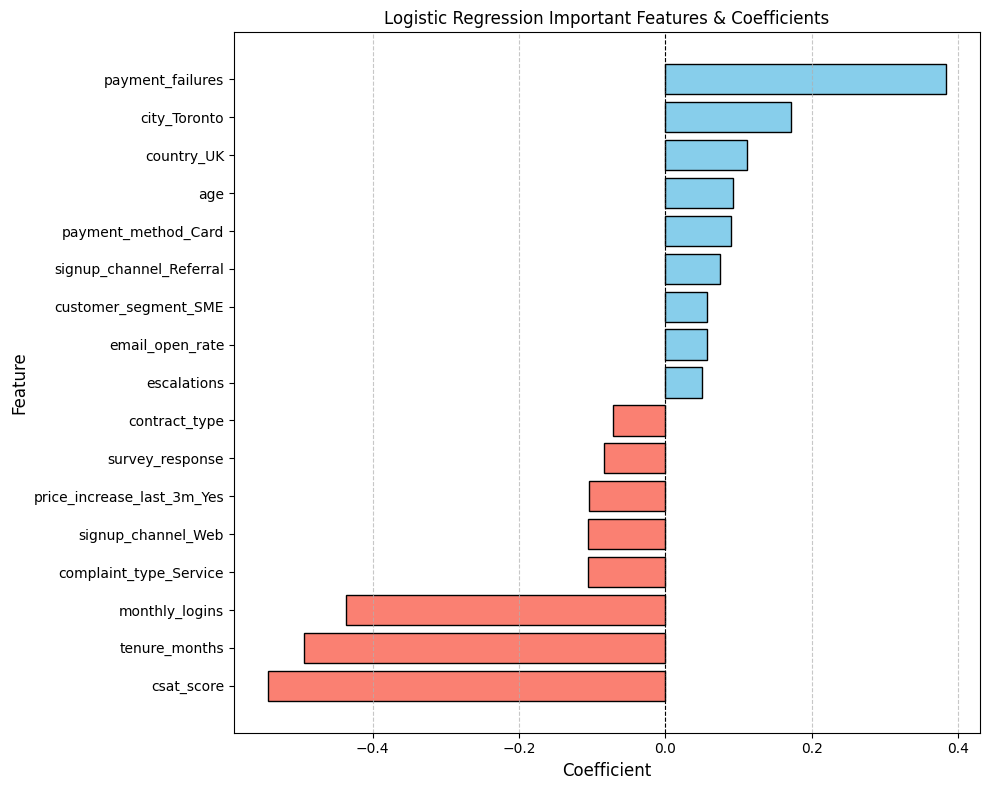

In [129]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in plot_lgr_df['coefs']]
plt.barh(plot_lgr_df['feature'], plot_lgr_df['coefs'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Important Features & Coefficients')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Churn Odds**    
**payment failures** is the number one predictor for churn. A customer with failed payments is significantly more likely to leave. A unit increase in payment failures raises odds of churn by the **percent_change** assuming all other variables remain constant.         
As these values go up, the probability of churn increases.  

On the other hand, **csat score** is the number one retention factor. High customer satisfaction is the strongest signal that a customer will stay. A unit increase in customer satisfaction scores decreases odds of churn by the **percent_change** assuming all other variables remain constant.

**monthly logins** - high product engagement is a major indicator of a healthy customer who will continue to stay.    

**tenure months** is another anchor - the longer a customer stays, the less likely it is to leave.           

As these values go up, the probability of churn decreases.

In [130]:
# Calculate odds ratios and percentage change in odds
L5_weight_coef_df['odds_ratio'] = np.exp(L5_weight_coef_df['coefs'])
L5_weight_coef_df['percent_change'] = (L5_weight_coef_df['odds_ratio'] - 1) * 100

# Sort by coefficient
L5_weight_coef_df = L5_weight_coef_df.sort_values(by='coefs', ascending=False)
L5_weight_coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
28,payment_failures,0.383319,1.467146,46.714606
8,city_Toronto,0.171665,1.187280,18.727990
4,country_UK,0.111369,1.117807,11.780687
19,age,0.092926,1.097381,9.738052
13,payment_method_Card,0.089011,1.093093,9.309314
11,signup_channel_Referral,0.074192,1.077013,7.701331
10,customer_segment_SME,0.056469,1.058093,5.809336
33,email_open_rate,0.056399,1.058020,5.801960
32,escalations,0.049553,1.050802,5.080170
2,gender_Male,0.045219,1.046257,4.625685


In [131]:
# Sort by coefs absolute values
L5_weight_coef_df['coefs'] = L5_weight_coef_df['coefs'].apply(abs)
L5_weight_coef_df = L5_weight_coef_df.sort_values(by = 'coefs', ascending = False)

L5_weight_coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
31,csat_score,0.542964,0.581023,-41.897668
20,tenure_months,0.494022,0.610168,-38.983235
21,monthly_logins,0.436524,0.646279,-35.372109
28,payment_failures,0.383319,1.467146,46.714606
8,city_Toronto,0.171665,1.187280,18.727990
4,country_UK,0.111369,1.117807,11.780687
17,complaint_type_Service,0.106345,0.899114,-10.088603
12,signup_channel_Web,0.106288,0.899166,-10.083391
16,price_increase_last_3m_Yes,0.104364,0.900898,-9.910240
19,age,0.092926,1.097381,9.738052


In [132]:
# Reset index
L5_weight_coef_df = L5_weight_coef_df.reset_index(drop=True)
L5_weight_coef_df.index = L5_weight_coef_df.index + 1
L5_weight_coef_df.index.name = "Rank"

L5_weight_coef_df.head(10)

,feature,coefs,odds_ratio,percent_change
Rank,,,,
1,csat_score,0.542964,0.581023,-41.897668
2,tenure_months,0.494022,0.610168,-38.983235
3,monthly_logins,0.436524,0.646279,-35.372109
4,payment_failures,0.383319,1.467146,46.714606
5,city_Toronto,0.171665,1.187280,18.727990
6,country_UK,0.111369,1.117807,11.780687
7,complaint_type_Service,0.106345,0.899114,-10.088603
8,signup_channel_Web,0.106288,0.899166,-10.083391
9,price_increase_last_3m_Yes,0.104364,0.900898,-9.910240


**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss for the different Logistic Regression models.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.    


In [133]:
# Build a dataframe summarizing the model properties
lgr_models_df = pd.DataFrame({
    'Model': ['Model L1','Model L2','Model L3','Model L4','Model L5'],
    'AUC': ['-', auc_L2, auc_L2, auc_L4, auc_L5],
    'Accuracy': [accuracy_L1, accuracy_L2, accuracy_L3, accuracy_L4, accuracy_L5],
    'Precision': [precision_L1, precision_L2, precision_L3, precision_L4, precision_L5],
    'Recall': [recall_L1, recall_L2, recall_L3, recall_L4, recall_L5],
    'F2 Score': [F2_score_L1, F2_score_L2, F2_score_L3, F2_score_L4, F2_score_L5],
    'Profit/Loss': [Profit_Loss_L1, Profit_Loss_L2, Profit_Loss_L3, Profit_Loss_L4, Profit_Loss_L5],
})
lgr_models_df

,Model,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Model L1,-,0.908060,0.800000,0.026846,0.033278,-70700
1,Model L2,0.733,0.657431,0.169179,0.677852,0.423303,2620
2,Model L3,0.733,0.311713,0.117504,0.973154,0.396175,21140
3,Model L4,0.741,0.367128,0.123902,0.946309,0.406574,20980
4,Model L5,0.733,0.304156,0.116987,0.979866,0.395879,21580


In [134]:
# Provide an interactive Plotly plot
fig = go.Figure()

# Primary y-axis
metrics = ['AUC','Accuracy', 'Precision', 'Recall', 'F2 Score']

for metric in metrics:
  fig.add_trace(
        go.Scatter(
          x=lgr_models_df['Model'],
          y=lgr_models_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=lgr_models_df['Model'],
          y=lgr_models_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
        )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='Model'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()


In [135]:
# Output the best Logistic Regression model performance metrics based on profit/loss
lgr_metrics_df = lgr_models_df.loc[[lgr_models_df["Profit/Loss"].idxmax()]]

lgr_metrics_df.to_csv("lgr_metrics.csv", index=False)

lgr_metrics_df.head()

,Model,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
4,Model L5,0.733,0.304156,0.116987,0.979866,0.395879,21580


In [136]:
# Output the first eight (8) features importance
model = lgr_metrics_df.iloc[0, 0]

if model == 'Model L3':
  lgr_features_df = L3_weight_coef_df.iloc[:8, :2]
elif model == 'Model L4':
  lgr_features_df = L4_weight_coef_df.iloc[:8, :2]
else:
  lgr_features_df = L5_weight_coef_df.iloc[:8, :2]

lgr_features_df.to_csv("lgr_features.csv", index=False)

print(lgr_features_df.head(8), '\n')
print(f'The best model is {model}.')

                     feature     coefs
Rank                                  
1                 csat_score  0.542964
2              tenure_months  0.494022
3             monthly_logins  0.436524
4           payment_failures  0.383319
5               city_Toronto  0.171665
6                 country_UK  0.111369
7     complaint_type_Service  0.106345
8         signup_channel_Web  0.106288 

The best model is Model L5.


**Sample Predictions**  

In [137]:
# Establish best model
model = lgr_metrics_df.iloc[0, 0]

if model == 'Model L3':
  model_opt = grid_search_L2_opt
  best_threshold = threshold_L3
elif model == 'Model L4':
  model_opt = grid_search_L4_opt
  best_threshold = threshold_L4
else:
  model_opt = grid_search_L5_opt
  best_threshold = threshold_L5

print(f'The best model is {model} and the best threshold is {best_threshold}.')

The best model is Model L5 and the best threshold is 0.25.


**Sample 1**     


In [138]:
# Obtain a sample from the test data
df_test1 = X_test[264:265]

print(df_test1.head().T, '\n')
print(f'Actual churn is {list(y_test[264:265])[0]}') # verify churn

                                 1862
gender                         Female
age                                62
country                        Canada
city                           Sydney
customer_segment           Individual
tenure_months                      18
signup_channel               Referral
contract_type                 Monthly
monthly_logins                     19
weekly_active_days                  1
avg_session_time            23.353293
features_used                       5
usage_growth_rate               -0.01
last_login_days_ago                 5
monthly_fee                        50
payment_method          Bank Transfer
payment_failures                    2
discount_applied                   No
price_increase_last_3m             No
support_tickets                     2
avg_resolution_time         24.419612
complaint_type                Billing
csat_score                        3.0
escalations                         0
email_open_rate                  0.33
marketing_cl

In [139]:
# Transfer the data to a dictionary
sample1 = {
    "gender": "Female",
    "age": 62,
    "country": "Canada",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 18,
    "signup_channel": "Referral",
    "contract_type": "Monthly",
    "monthly_logins": 19,
    "weekly_active_days": 1,
    "avg_session_time": 23.353293,
    "features_used": 5,
    "usage_growth_rate": -0.01,
    "last_login_days_ago": 5,
    "monthly_fee": 50,
    "payment_method": "Bank Transfer",
    "payment_failures": 2,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 2,
    "avg_resolution_time": 24.419612,
    "complaint_type": "Billing",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.33,
    "marketing_click_rate": 0.49,
    "nps_score": -15,
    "survey_response": "Satisfied",
    "referral_count": 1,
    "tenure_fee_interaction": 900
}

In [140]:
# Calculate churn probability of the sample and provide churn of the sample
probability1 = model_opt.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability1:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.77









**Sample 2**     


In [141]:
# Obtain a sample from the test data
df_test2 = X_test[399:400]

print(df_test2.head().T, '\n')
print(f'The actual churn is {list(y_test[399:400])[0]}') # verify churn

                             1495
gender                       Male
age                            33
country                     India
city                     New York
customer_segment              SME
tenure_months                  40
signup_channel             Mobile
contract_type           Quarterly
monthly_logins                 10
weekly_active_days              2
avg_session_time        20.705153
features_used                   4
usage_growth_rate           -0.33
last_login_days_ago             0
monthly_fee                    50
payment_method               Card
payment_failures                0
discount_applied               No
price_increase_last_3m         No
support_tickets                 0
avg_resolution_time     31.927794
complaint_type          Technical
csat_score                    3.0
escalations                     0
email_open_rate              0.17
marketing_click_rate         0.15
nps_score                      70
survey_response           Neutral
referral_count

In [142]:
# Transfer the data to a dictionary
sample2 = {
    "gender": "Male",
    "age": 33,
    "country": "India",
    "city": "New York",
    "customer_segment": "SME",
    "tenure_months": 40,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 10,
    "weekly_active_days": 2,
    "avg_session_time": 20.705153,
    "features_used": 4,
    "usage_growth_rate": -0.33,
    "last_login_days_ago": 0,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 31.927794,
    "complaint_type": "Technical",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.17,
    "marketing_click_rate": 0.15,
    "nps_score": 70,
    "survey_response": "Neutral",
    "referral_count": 2,
    "tenure_fee_interaction": 2000
}

In [143]:
# Calculate churn probability of the sample and provide churn of the sample
probability2 = model_opt.predict_proba(pd.DataFrame([sample2]))[:, 1][0]

if probability2 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability2:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.42


**Sample 3**    


In [144]:
# Obtain a sample from the test data
df_test3 = X_test[999:1000]

print(df_test3.head().T, '\n')
print(f'The actual churn is {list(y_test[999:1000])[0]}') # verify churn

                              5713
gender                      Female
age                             51
country                      India
city                         Dhaka
customer_segment        Individual
tenure_months                   12
signup_channel              Mobile
contract_type            Quarterly
monthly_logins                  12
weekly_active_days               7
avg_session_time         10.737885
features_used                    7
usage_growth_rate            -0.11
last_login_days_ago              4
monthly_fee                     50
payment_method                Card
payment_failures                 0
discount_applied               Yes
price_increase_last_3m          No
support_tickets                  3
avg_resolution_time      23.828534
complaint_type             Billing
csat_score                     4.0
escalations                      0
email_open_rate               0.18
marketing_click_rate          0.48
nps_score                       40
survey_response     

In [145]:
# Place the sample data in a dictionary
sample3 = {
    "gender": "Female",
    "age": 51,
    "country": "India",
    "city": "Dhaka",
    "customer_segment": "Individual",
    "tenure_months": 12,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 12,
    "weekly_active_days": 7,
    "avg_session_time": 10.737885,
    "features_used": 7,
    "usage_growth_rate": -0.11,
    "last_login_days_ago": 4,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "Yes",
    "price_increase_last_3m": "No",
    "support_tickets": 3,
    "avg_resolution_time": 23.828534,
    "complaint_type": "Billing",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.18,
    "marketing_click_rate": 0.48,
    "nps_score": 40,
    "survey_response": "Satisfied",
    "referral_count": 2,
    "tenure_fee_interaction": 600
}

In [146]:
# Calculate churn probability of the sample and provide churn of the sample
probability3 = model_opt.predict_proba(pd.DataFrame([sample3]))[:, 1][0]

if probability3 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability3:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.48


**Sample 4**     


In [147]:
# Obtain another sample from the test data
df_test4 = X_test[125:126]

print(df_test4.head().T, '\n')
print(f'The actual churn is {list(y_test[125:126])[0]}') # verify churn

                                 5786
gender                         Female
age                                51
country                    Bangladesh
city                           London
customer_segment           Individual
tenure_months                      58
signup_channel               Referral
contract_type               Quarterly
monthly_logins                      0
weekly_active_days                  3
avg_session_time            14.899728
features_used                       5
usage_growth_rate                0.11
last_login_days_ago                14
monthly_fee                        20
payment_method          Bank Transfer
payment_failures                    0
discount_applied                   No
price_increase_last_3m             No
support_tickets                     0
avg_resolution_time         13.387985
complaint_type              Technical
csat_score                        4.0
escalations                         0
email_open_rate                  0.22
marketing_cl

In [148]:
# Place the sample data in a dictionary
sample4 = {
    "gender": "Female",
    "age": 51,
    "country": "Bangladesh",
    "city": "London",
    "customer_segment": "Individual",
    "tenure_months": 58,
    "signup_channel": "Referral",
    "contract_type": "Quarterly",
    "monthly_logins": 0,
    "weekly_active_days": 3,
    "avg_session_time": 14.899728,
    "features_used": 5,
    "usage_growth_rate": 0.11,
    "last_login_days_ago": 14,
    "monthly_fee": 20,
    "payment_method": "Bank Transfer",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 13.387985,
    "complaint_type": "Technical",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.22,
    "marketing_click_rate": 0.19,
    "nps_score": 50,
    "survey_response": "Satisfied",
    "referral_count": 0,
    "tenure_fee_interaction": 1160
}

In [149]:
# Calculate churn probability of the sample and provide churn of the sample
probability4 = model_opt.predict_proba(pd.DataFrame([sample4]))[:, 1][0]

if probability4 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability4:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.28


**Sample 5**    


In [150]:
# Obtain another sample from the test data
df_test5 = X_test[1125:1126]

print(df_test5.head().T, '\n')
print(f'The actual churn is {list(y_test[1125:1126])[0]}') # verify churn

                              6970
gender                      Female
age                             38
country                         UK
city                        Sydney
customer_segment        Individual
tenure_months                   14
signup_channel                 Web
contract_type              Monthly
monthly_logins                  10
weekly_active_days               3
avg_session_time         10.354267
features_used                    5
usage_growth_rate            -0.14
last_login_days_ago              3
monthly_fee                     50
payment_method                Card
payment_failures                 1
discount_applied                No
price_increase_last_3m          No
support_tickets                  1
avg_resolution_time       9.362325
complaint_type             Service
csat_score                     3.0
escalations                      0
email_open_rate               0.56
marketing_click_rate          0.49
nps_score                       87
survey_response     

In [151]:
# Place the sample data in a dictionary
sample5 = {
    "gender": "Female",
    "age": 38,
    "country": "UK",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 14,
    "signup_channel": "Web",
    "contract_type": "Monthly",
    "monthly_logins": 10,
    "weekly_active_days": 3,
    "avg_session_time": 10.354267,
    "features_used": 5,
    "usage_growth_rate": -0.14,
    "last_login_days_ago": 3,
    "monthly_fee": 50,
    "total_revenue": 700,
    "payment_method": "Card",
    "payment_failures": 1,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 1,
    "avg_resolution_time": 9.362325,
    "complaint_type": "Service",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.56,
    "marketing_click_rate": 0.49,
    "nps_score": 87,
    "survey_response": "Neutral",
    "referral_count": 0,
    "tenure_fee_interaction": 700
}

In [152]:
# Calculate churn probability of the sample and provide churn of the sample
probability5 = model_opt.predict_proba(pd.DataFrame([sample5]))[:, 1][0]

if probability5 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability5:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.78
